In [3]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import itertools
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from shapely.affinity import rotate
import ssam_groups as groups
from ssam_groups import cohorts
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# Oil injection file 
oil_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles')
oil_paths = sorted([p for p in oil_root.glob('MPRI2_Scenario_5b_2019-01-20_10000_WSF.nc')])
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]

In [4]:
# Read in salish sea atlantis output files.
#control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/control_5b_1_2019-01-20_WSF_v6722/outputSalishSea.nc"
control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/highres-control-3y-2019-2022/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])

In [5]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/')
scenario_paths = sorted([p for p in scenario_root.glob('contam_5b_1_2019-01-20_WSF*/outputSalishSea.nc')])
for path in scenario_paths:
    print(path.parent.stem)

contam_5b_1_2019-01-20_WSF_v6722
contam_5b_1_2019-01-20_WSF_v6722_1
contam_5b_1_2019-01-20_WSF_v6722_2
contam_5b_1_2019-01-20_WSF_v6722_3
contam_5b_1_2019-01-20_WSF_v6722_4
contam_5b_1_2019-01-20_WSF_v6722_5
contam_5b_1_2019-01-20_WSF_v6722_movedepend


In [6]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [7]:
# start and end time of data display, after burn-in
start = 0
end = 1825000

## Map spill extent

In [23]:
# Reading in Atlantis map
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]

map_angle = -37

geom = data_df.unary_union
centroid = geom.centroid
ssam_rotated = data_df.copy()
ssam_rotated["geometry"] = data_df.geometry.apply(
    lambda g: rotate(g, map_angle, origin=geom.centroid)
    
)

land_df = data_df.loc[land_boxes]
jdf_df = data_df.loc[ssam_rotated.Region=='Juan de Fuca']
hs_df = data_df.loc[ssam_rotated.Region=='Howe Sound']
strait_df = data_df.loc[ssam_rotated.Region=='Strait of Georgia']
ps_df = data_df.loc[ssam_rotated.Region=='Puget Sound']

TP-1 BOX_ID
1     655575973
2     682702420
3     494069246
4     446328916
5     261808665
8     485601055
9     288060859
33    181216243
34    116214640
37     61024272
60    322474724
Name: AREA, dtype: int64 BOX_ID
1     0.003389
2     0.004656
3     0.002481
4     0.005581
5     0.004407
8     0.012111
9     0.014786
33    0.008563
34    0.003598
37    0.003807
60    0.010568
Name: TPAH, dtype: float64


No handles with labels found to put in legend.


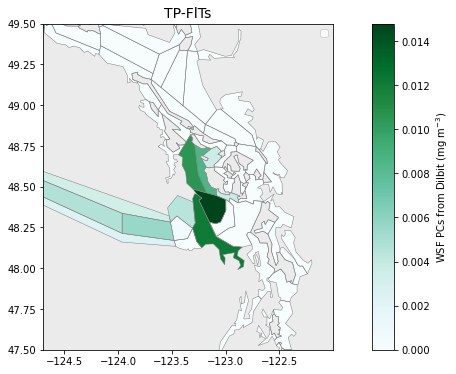

In [6]:
fig = plt.figure(figsize=(18, 6), facecolor='white') #figsize=(9, 12)
gs = plt.GridSpec(1, len(oil_files), wspace=0.5, hspace=0.2, height_ratios=[1],)

for file, oil_path in zip(oil_files, oil_paths):
    date = str(oil_path).split(sep = '_')[3]
    label = 'TP-'+ str(groups.conditions_with_letters[str(groups.simulations[groups.conditions[date]])])
    position = int(str(groups.simulations[groups.conditions[date]]))-1
    oil_b = file.variables['TPAH']
    #oil_b = oil_b[8,:] / 1e6
    oil_b = oil_b.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.001] 
    print('TP-'+str(groups.simulations[groups.conditions[date]]), oil_df.AREA, oil_df.TPAH)

    ax = fig.add_subplot(gs[0, position], facecolor = '#EBEBEB')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=-0.5)
    ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax,cmap=cm.BuGn, legend_kwds={'label': 'WSF PCs from Dilbit (mg m$^{-3}$)'}, #vmax=80,
    #ax = data_df.plot(column = 'BOTZ', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'depth (m)'},
    legend=True, 
    )
    ax.set_title(label, fontsize = 14)
    ax.set_xlim(-124.7)
    ax.set_ylim(47.5, 49.5)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
    #oil_df.plot(ax=ax, color='red',linewidths=0.5)
ax.legend()
#fig.supylabel('Turn Point', fontsize = 16); #color=hex_colour
#fig.savefig("Figures/spill-map-TP.png", dpi=300, bbox_inches='tight')

In [9]:
affected_boxes = [1, 2, 3, 4, 5, 8, 9, 33, 34, 37, 60]
#affected_df = ssam_rotated.loc[affected_boxes]

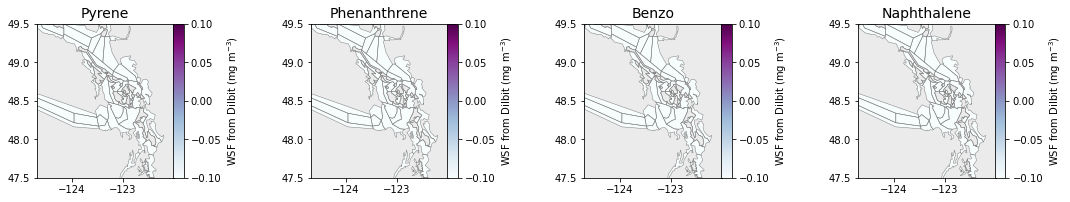

In [12]:
for scenario in scenario_datasets:
    fig = plt.figure(figsize=(18, 6), facecolor='white') #figsize=(9, 12)
    gs = plt.GridSpec(1, len(groups.pahs), wspace=0.5, hspace=0.2, height_ratios=[1],)

    position = 0

    for pah in groups.pahs:
        oil_tbl = scenario.variables[pah]
        oil_b = oil_tbl.sum(axis=(0,2))

        # Add scenario data to Atlantis spatial data
        data_df[str(pah)] = oil_b
        data_df.loc[land_boxes, str(pah)] = 0

        ax = fig.add_subplot(gs[0, position], facecolor = '#EBEBEB')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=-0.5)
        ax = data_df.plot(column = str(pah), ax=ax, cax=cax,cmap=cm.BuPu, legend_kwds={'label': 'WSF from Dilbit (mg m$^{-3}$)'},
        #ax = ssam_rotated.plot(column = 'BOTZ', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'depth (m)'},
        legend=True, 
        )
        ax.set_title(pah, fontsize = 14)
        ax.set_xlim(-124.7)
        ax.set_ylim(47.5, 49.5)
        data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
        land_df.plot(ax=ax, color='#EBEBEB')
        position = position+1
    #fig.supylabel('Turn Point', fontsize = 16); #color=hex_colour
    #fig.savefig("Figures/spill-map-TP.png", dpi=300, bbox_inches='tight')

## Oil onjection

/home/rlovindeer/conda_envs/parcels-dev/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


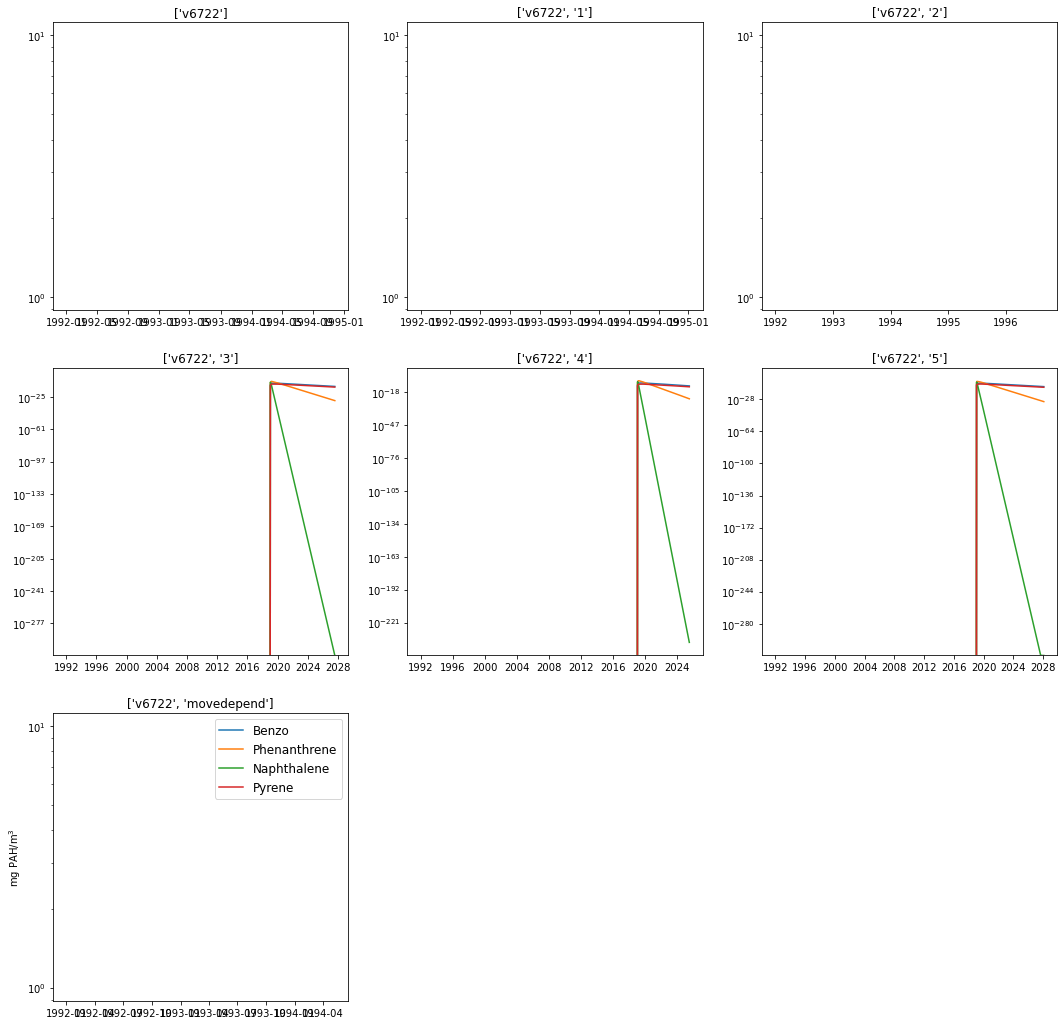

In [6]:
fig = plt.figure(figsize=(18, 18), facecolor='white')
gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1])

names = []
for scenario, path, i in zip(scenario_datasets,scenario_paths,range(0,len(scenario_datasets))):
    nm = path.parent.stem.split(sep = '_')
    names.append(str(nm[5:7]))
    
    if i < 3:
        position = 0, i
    elif i > 5: 
        position = 2, i-6
    else :
        position = 1, i-3
    ax = fig.add_subplot(gs[position])
    for pah in groups.pahs:
        contam_tbl = scenario.variables[str(pah)][:,:,0:6]
        contam_t = contam_tbl.sum(axis=(1,2))
        ax.semilogy(scenario.t, contam_t)
    ax.set_title(str(nm[5:7]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(groups.pahs, fontsize=12)

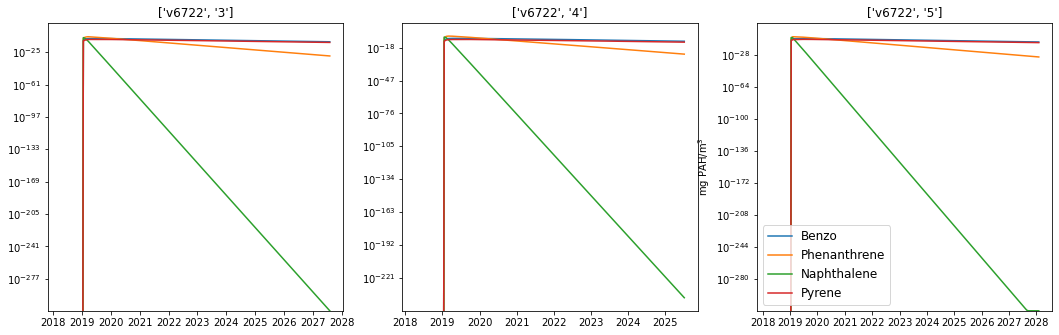

In [21]:
start = 480
fig = plt.figure(figsize=(18, 18), facecolor='white')
gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1])

names = []
for scenario, path, i in zip(scenario_datasets[3:6],scenario_paths[3:6],range(0,len(scenario_datasets[3:6]))):
    nm = path.parent.stem.split(sep = '_')
    names.append(str(nm[5:7]))
    
    if i < 3:
        position = 0, i
    elif i > 5: 
        position = 2, i-6
    else :
        position = 1, i-3
    ax = fig.add_subplot(gs[position])
    for pah in groups.pahs:
        contam_tbl = scenario.variables[str(pah)][start:end,:,0:6]
        contam_t = contam_tbl.sum(axis=(1,2))
        ax.semilogy(scenario.t[start:end], contam_t)
    ax.set_title(str(nm[5:7]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(groups.pahs, fontsize=12)

In [13]:
scenario.t.size

660

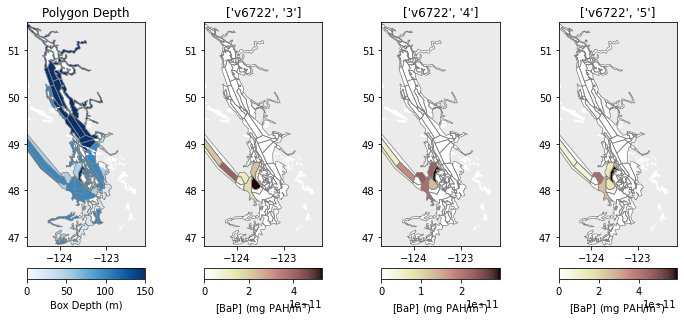

In [24]:
fig = plt.figure(figsize=(18, 9), facecolor='white') #figsize=(9, 12)
gs = plt.GridSpec(1, 6, wspace=0.5, hspace=0.2, height_ratios=[1],)

ax = fig.add_subplot(gs[0, 0], facecolor = '#EBEBEB')
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.3, )
ax = ssam_rotated.plot(column = 'BOTZ', ax=ax, cmap=cm.Blues, cax=cax, vmax = 150, #
    legend=True, legend_kwds={'label': 'Box Depth (m)', "orientation": "horizontal"
    },)
ssam_rotated.boundary.plot(ax=ax, color='grey', linewidths=0.7)
land_df.plot(ax=ax, color='white')
ax.set_aspect("equal")
ax.set_ylim(46.8, 51.6)
ax.set_xlim(-124.7)
ax.set_title('Polygon Depth')


position =  1

for scenario, path in zip(scenario_datasets[3:6],scenario_paths[3:6]):
    nm = path.parent.stem.split(sep = '_')
    name = str(nm[5:7])

    benzo = scenario.Benzo[500]
    benzo = benzo.sum(axis=1)
    ssam_rotated['benzo'] = benzo
    
    ax = fig.add_subplot(gs[0, position], facecolor = '#EBEBEB')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=0.3, )
    ax = ssam_rotated.plot(column = 'benzo', ax=ax, cmap=cm.pink_r, cax=cax, #vmax = 75, #
        legend=True, legend_kwds={'label': '[BaP] (mg PAH/m$^3$)', "orientation": "horizontal"
        },)
    ssam_rotated.boundary.plot(ax=ax, color='grey', linewidths=0.7)
    land_df.plot(ax=ax, color='white')
    ax.set_title(name)
    ax.set_aspect("equal")
    ax.set_ylim(46.8, 51.6)
    ax.set_xlim(-124.7)
    position = position+1 

## Impacts

In [15]:
def aggregate_boxplot_data_pelagic(bio_group, bio_group_name, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '5 years later', '10 years later', '20 years later']

    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+nm[2]
            hex_colour = '#863092'
            control = control_73
            if '2019'in year:
                end_days = days2019summer_73
            else: 
                end_days = days2020summer_73
            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+nm[2]
            hex_colour = '#6DB48E'
            control = control_90
            if '2019'in year:
                end_days = days2019winter_90
            else:
                end_days = days2020winter_90
        elif nm[1] == '6a':
            scenario_name = 'EB-'+nm[2]
            hex_colour = '#2F61A4'
            control = control_90
            if '2019'in year:
                end_days = days2019summer_90
            else:
                end_days = days2020summer_90
        elif nm[1] == '7a':
            scenario_name = 'JF-'+nm[2]
            hex_colour = '#A27170'
            control = control_73
            if '2019'in year:
                end_days = days2019winter_73
            else: 
                end_days = days2020winter_73

        # if '2019-01'in year:
        #     end_days = days2019winter
        # elif '2020-01' in year:
        #     end_days = days2020winter
        # elif '2019-07' in year:
        #     end_days = days2019summer
        # elif '2020-07' in year:
        #     end_days = days2020summer

        results = []
        for day in end_days: 
            start = day - 30
            p_oiled = 0
            p_control = 0
            for species in bio_group: 
                p_oiled = p_oiled + np.ma.filled(scenario.variables[bio_group[species] + '_N'][start:day, location, 0:6], np.nan)
                p_control = p_control + np.ma.filled(control.variables[bio_group[species] + '_N'][start:day, location, 0:6], np.nan)
            
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()
            p_control = p_control.sum(axis=(1, 2)).mean()
            p_ratio = (p_oiled / p_control - 1) * 100
            results.append(p_ratio)
            
        for label, value in zip(data_labels, results):
            all_results.append({
            'bio_group': bio_group_name,
            'time_label': label,
            'scenario': scenario_name,
            'percent_change': value,
            'sensitivity': sensitivity[bio_group_name],
            'sensitivity_negative': -sensitivity[bio_group_name],
        })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI-1/aggregated-data-"+bio_group_name+".csv")

In [22]:
def aggregate_boxplot_data_vertebrates(bio_group, bio_group_name, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '5 years later', '10 years later', '20 years later']

    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+nm[2]
            hex_colour = '#863092'
            control = control_73
            if '2019'in year:
                end_days = days2019summer_73
            else: 
                end_days = days2020summer_73
            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+nm[2]
            hex_colour = '#6DB48E'
            control = control_90
            if '2019'in year:
                end_days = days2019winter_90
            else:
                end_days = days2020winter_90
        elif nm[1] == '6a':
            scenario_name = 'EB-'+nm[2]
            hex_colour = '#2F61A4'
            control = control_90
            if '2019'in year:
                end_days = days2019summer_90
            else:
                end_days = days2020summer_90
        elif nm[1] == '7a':
            scenario_name = 'JF-'+nm[2]
            hex_colour = '#A27170'
            control = control_73
            if '2019'in year:
                end_days = days2019winter_73
            else: 
                end_days = days2020winter_73

        # if '2019-01'in year:
        #     end_days = days2019winter
        # elif '2020-01' in year:
        #     end_days = days2020winter
        # elif '2019-07' in year:
        #     end_days = days2019summer
        # elif '2020-07' in year:
        #     end_days = days2020summer

        results = []
        for day in end_days: 
            aggregate_ratio = 0
            start = day - 30
            for species in bio_group:

                species_ratio = 0

                numCohorts = groups.cohorts[bio_group[species]]
                for cohort in range (1, numCohorts+1):
                    new_species = bio_group[species] + str(cohort)
                
                    o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][start:day, location, 0:6], np.nan)
                    o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][start:day, location, 0:6], np.nan)
                    o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][start:day, location, 0:6], np.nan)

                    c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][start:day, location, 0:6], np.nan)
                    c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][start:day, location, 0:6], np.nan)
                    c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][start:day, location, 0:6], np.nan)

                    o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                    o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

                    c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                    c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

                    cohort_ratio = (o_weightatage / c_weightatage - 1) * 100
                    #print(scenario_name, species, cohort, cohort_ratio)
                    species_ratio = species_ratio + cohort_ratio

                final_species_ratio = species_ratio/numCohorts
                #print(scenario_name, species, final_species_ratio)
                aggregate_ratio = aggregate_ratio + final_species_ratio
            
            results.append(aggregate_ratio/len(bio_group))
            #print(scenario_name, bio_group_name, aggregate_ratio, aggregate_ratio/len(bio_group))
            
        for label, value in zip(data_labels, results):
            all_results.append({
            'bio_group': bio_group_name,
            'time_label': label,
            'scenario': scenario_name,
            'percent_change': value,
            'sensitivity': sensitivity[bio_group_name],
            'sensitivity_negative': -sensitivity[bio_group_name],
        })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI-1/aggregated-data-"+bio_group_name+".csv")

In [8]:
def boxplot_data_benthic(bio_group, location=groups.salish_sea):
    results = []
    start = 500
    end = 600
    for scenario, path in zip(scenario_datasets[3:6],scenario_paths[3:6]):
        nm = str(path.parent.stem).split(sep='_')
        scenario_name = str(nm[5:7])

        p_oiled = 0
        p_control = 0
        for species in bio_group: 
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][start:end, location], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location], np.nan)
            p_oiled = p_oiled.sum(axis=1).mean()
            p_control = p_control.sum(axis=1).mean()
            p_ratio = (p_oiled / p_control - 1) * 100
            
            results.append({
            'bio_group': species,
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
        })

    df = pd.DataFrame(results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/box-data-benthos.csv")

In [33]:
boxplot_data_benthic(groups.benthos)

In [41]:
results_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/')
results_paths = sorted([p for p in results_root.glob('box-data-benthos.csv')])
box_data = []
for file in results_paths:
    df1 = pd.read_csv(file)
    box_data.append(df1[['bio_group', 'scenario', 'percent_change','sensitivity','sensitivity_negative']])

box_data_df = pd.concat(aggregated_data, ignore_index=True)
#box_data_df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI-1/aggregated_data.csv")

In [9]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/box-data-benthos.csv")

In [10]:
scenarios = df['scenario'].unique()
bio_groups = df['bio_group'].unique()

hatches = ['oo', '///', 'xx', '++']
alphas = [0.5, 0.75, 0.3, 1]
hex_colour = '#6DB48E'
#colors = plt.cm.tab10.colors


/tmp/ipykernel_1999892/3611251386.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(bio_groups, fontsize=20)


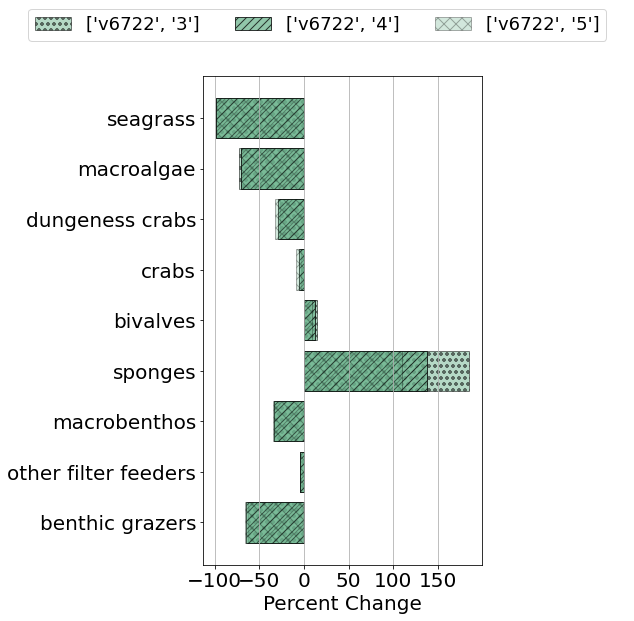

In [14]:
x_lim = None

n_rows = len(bio_groups)
if n_rows < 7:
    n_rows = 7
elif n_rows >10:
    n_rows = 15
else:
    n_rows = n_rows
fig, ax = plt.subplots(1, 1, figsize=(5, n_rows), sharey=True)

y_pos = np.arange(len(bio_groups))

for j, scenario in enumerate(scenarios):
    df_plot = df[(df['scenario'] == scenario)]
    df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
    offset = (j - len(scenarios)/2)
    ax.barh(bio_groups, df_plot['percent_change'], label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
ax.barh(bio_groups, df_plot['sensitivity'], color='grey', alpha=0.3)
ax.barh(bio_groups, df_plot['sensitivity_negative'], color='grey', alpha=0.3)
ax.xaxis.grid(True)
xlabels = ax.get_xticklabels()
plt.setp(xlabels, fontsize=20)

#ax.set_title('', fontsize=20)
#ax.set_yticks(y_pos)
ax.set_yticklabels(bio_groups, fontsize=20) 
ax.set_xlim(x_lim)
ax.set_xlabel("Percent Change", fontsize=20)

fig.legend(scenarios, loc='upper center', ncol=len(scenarios), fontsize=18) 
plt.show()

In [45]:
df_plot

,Unnamed: 0,scenario,percent_change,sensitivity,sensitivity_negative
bio_group,,,,,
benthic grazers,18,"['v6722', '5']",-66.134886,0.400,-0.400
other filter feeders,19,"['v6722', '5']",-3.980206,0.000,-0.000
macrobenthos,20,"['v6722', '5']",-34.625136,0.090,-0.090
sponges,21,"['v6722', '5']",109.907550,0.000,-0.000
bivalves,22,"['v6722', '5']",9.584928,0.020,-0.020
crabs,23,"['v6722', '5']",-8.408132,0.020,-0.020
dungeness crabs,24,"['v6722', '5']",-32.097829,0.004,-0.004
macroalgae,25,"['v6722', '5']",-69.806914,0.060,-0.060
seagrass,26,"['v6722', '5']",-98.457222,0.060,-0.060


For presentations

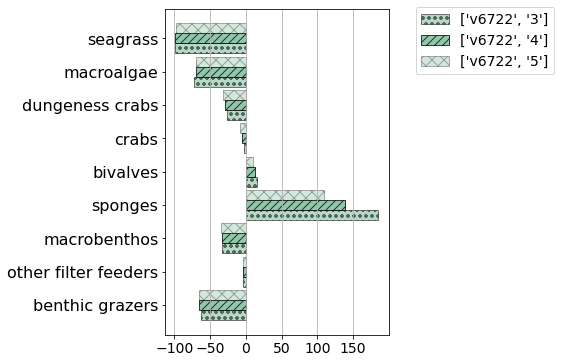

In [25]:
x_lim = None

n_rows = len(bio_groups)
if n_rows < 7:
    n_rows = 7
elif n_rows >10:
    n_rows = 15
else:
    n_rows = n_rows

fig, ax = plt.subplots(1, 1, figsize=(4, 6), sharey=True)

bar_width = 0.9 / len(scenarios)  
y_pos = np.arange(len(bio_groups))

for j, scenario in enumerate(scenarios):
    df_plot = df[(df['scenario'] == scenario)]
    df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
    offset = (j - len(scenarios)/2) * bar_width + bar_width/2

    ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
ax.barh(bio_groups, df_plot['sensitivity'], color='grey', alpha=0.3)
ax.barh(bio_groups, df_plot['sensitivity_negative'], color='grey', alpha=0.3)
ax.xaxis.grid(True)
xlabels = ax.get_xticklabels()
plt.setp(xlabels, fontsize=14)

ax.set_yticks(y_pos)
ax.set_yticklabels(bio_groups, fontsize=16) 
ax.set_xlim(x_lim)
#ax.set_xlabel("Percent Change", fontsize=16)

fig.legend(scenarios, bbox_to_anchor=(1.5, 0.9),  fontsize=14) #bbox_to_anchor=(0.8, 1.2) ncol=len(scenarios),
plt.show()